### Importations de bibliothèques
Cette cellule importe toutes les bibliothèques et modules nécessaires au projet, y compris PyTorch pour l'apprentissage profond, torchvision pour les jeux de données et les transformations, numpy et matplotlib pour les opérations numériques et le traçage, et scikit-learn pour les métriques d'évaluation.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

### Chargement et prétraitement des données
Cette cellule définit les transformations de données (conversion des images en tenseurs et leur normalisation), charge le jeu de données FashionMNIST pour l'entraînement et les tests, puis crée des chargeurs de données pour alimenter efficacement les modèles par lots.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 21.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 481kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.33MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.37MB/s]


### Étiquettes de classe
Cette cellule définit une liste d'étiquettes de chaîne correspondant aux 10 classes du jeu de données FashionMNIST. Ces étiquettes sont utilisées pour une meilleure interprétabilité des résultats et des visualisations.

In [ ]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

### Visualisation d'exemples d'images
Cette cellule récupère un lot d'images et leurs étiquettes à partir du chargeur de données d'entraînement, puis affiche les 10 premières images avec les noms de leurs classes respectives. Cela aide à comprendre le contenu du jeu de données.

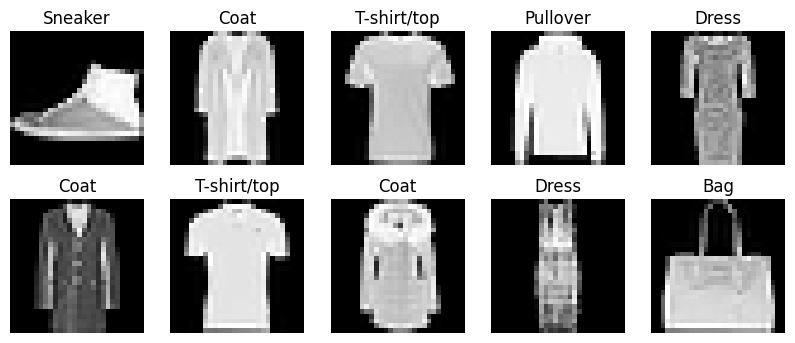

In [ ]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(classes[labels[i]])
    plt.axis("off")

plt.show()

### Fonction de corrélation croisée 2D personnalisée
Cette cellule définit une fonction Python `corr2d` qui implémente l'opération de corrélation croisée 2D (qui est le cœur de la convolution dans les réseaux neuronaux, souvent sans retournement du noyau pour des raisons de simplicité ici) à partir de zéro, en prenant une matrice d'entrée `X` et un noyau `K`.

In [ ]:
def corr2d(X, K):
    h, w = K.shape
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))

    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = torch.sum(X[i:i+h, j:j+w] * K)

    return Y

### Démonstration de la fonction `corr2d` personnalisée
Cette cellule démontre l'utilisation de la fonction `corr2d` personnalisée avec une petite matrice d'entrée `X` et un noyau `K` échantillon, puis imprime la matrice de sortie `Y` résultante.

In [ ]:
X = torch.tensor([
    [1., 2., 3.],
    [4., 5., 6.],
    [7., 8., 9.]
])

K = torch.tensor([
    [1., 0.],
    [0., -1.]
])

Y = corr2d(X, K)

print(Y)

tensor([[-4., -4.],
        [-4., -4.]])


### Comparaison de `corr2d` personnalisé avec `nn.Conv2d` de PyTorch
Cette cellule compare la sortie de la fonction `corr2d` personnalisée avec la couche `nn.Conv2d` intégrée de PyTorch. Elle remodèle l'entrée et le noyau pour correspondre au format de tenseur attendu par PyTorch, puis applique la convolution, démontrant l'équivalence.

In [ ]:
X_torch = X.reshape(1, 1, 3, 3)
K_torch = K.reshape(1, 1, 2, 2)

conv = nn.Conv2d(
    in_channels=1,
    out_channels=1,
    kernel_size=2,
    bias=False
)

conv.weight.data = K_torch

Y_torch = conv(X_torch)

print(Y_torch)

tensor([[[[-4., -4.],
          [-4., -4.]]]], grad_fn=<ConvolutionBackward0>)


### Fonction de max-pooling 2D personnalisée
Cette cellule définit une fonction Python `max_pool2d` qui implémente l'opération de max-pooling 2D à partir de zéro. Elle prend une matrice d'entrée `X` et un tuple `pool_size`, renvoyant la matrice sous-échantillonnée.

In [ ]:
def max_pool2d(X, pool_size):
    p_h, p_w = pool_size
    Y = torch.zeros((X.shape[0] // p_h, X.shape[1] // p_w))

    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            window = X[i*p_h:(i+1)*p_h, j*p_w:(j+1)*p_w]
            Y[i, j] = torch.max(window)

    return Y

### Démonstration de la fonction `max_pool2d` personnalisée
Cette cellule démontre l'utilisation de la fonction `max_pool2d` personnalisée avec une matrice d'entrée `X` échantillon et une taille de pooling de `(2, 2)`, puis imprime le résultat.

In [ ]:
X = torch.tensor([
    [1., 3., 2., 4.],
    [5., 6., 1., 2.],
    [7., 2., 8., 1.],
    [3., 4., 5., 6.]
])

print(max_pool2d(X, (2, 2)))

tensor([[6., 4.],
        [7., 8.]])


### Fonction de moyenne pooling 2D personnalisée
Cette cellule définit une fonction Python `avg_pool2d` qui implémente l'opération de moyenne pooling 2D à partir de zéro. Similaire au max-pooling, elle prend une matrice d'entrée `X` et une `pool_size`.

In [ ]:
def avg_pool2d(X, pool_size):
    p_h, p_w = pool_size
    Y = torch.zeros((X.shape[0] // p_h, X.shape[1] // p_w))

    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            window = X[i*p_h:(i+1)*p_h, j*p_w:(j+1)*p_w]
            Y[i, j] = torch.mean(window)

    return Y

### Démonstration de la fonction `avg_pool2d` personnalisée
Cette cellule démontre l'utilisation de la fonction `avg_pool2d` personnalisée avec la même matrice d'entrée `X` échantillon et une taille de pooling de `(2, 2)`, puis imprime le résultat.

In [ ]:
print(avg_pool2d(X, (2, 2)))

tensor([[3.7500, 2.2500],
        [4.0000, 5.0000]])


### Comparaison du pooling personnalisé avec les couches de pooling de PyTorch
Cette cellule compare la sortie des fonctions de max et de moyenne pooling personnalisées avec les couches `nn.MaxPool2d` et `nn.AvgPool2d` intégrées de PyTorch, démontrant leur équivalence.

In [ ]:
X_torch = X.reshape(1, 1, 4, 4)

max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)

print("MaxPool PyTorch :")
print(max_pool(X_torch))

print("AvgPool PyTorch :")
print(avg_pool(X_torch))

MaxPool PyTorch :
tensor([[[[6., 4.],
          [7., 8.]]]])
AvgPool PyTorch :
tensor([[[[3.7500, 2.2500],
          [4.0000, 5.0000]]]])


### Définition du modèle ImageMLP
Cette cellule définit un modèle de perceptron multicouche (MLP) simple nommé `ImageMLP` utilisant `nn.Sequential`. Il aplatit l'image d'entrée et la traite à travers une série de couches entièrement connectées (linéaires) avec des activations ReLU.

In [ ]:
class ImageMLP(nn.Module):
    def __init__(self):
        super(ImageMLP, self).__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

### Définition du modèle LeNetCNN
Cette cellule définit un modèle de réseau neuronal convolutif (CNN) inspiré par LeNet. Il se compose de couches de convolution, d'activations ReLU et de couches de max-pooling pour l'extraction de caractéristiques, suivies de couches entièrement connectées pour la classification.

In [ ]:
class LeNetCNN(nn.Module):
    def __init__(self):
        super(LeNetCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(6, 16, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

### Configuration du périphérique
Cette cellule détermine si un GPU compatible CUDA est disponible et définit la variable `device` en conséquence. Cela permet de déplacer les modèles et les données vers le GPU pour un calcul plus rapide si disponible, sinon, il utilise le CPU par défaut.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

Device utilisé : cpu


### Fonction d'entraînement du modèle
Cette cellule définit une fonction `train_model` qui encapsule la boucle d'entraînement pour un modèle PyTorch donné. Elle gère le déplacement du modèle et des données vers le périphérique spécifié, calcule la perte à l'aide de `CrossEntropyLoss`, optimise les paramètres à l'aide d'Adam et évalue la précision sur l'ensemble de test à la fin de chaque époque.

In [ ]:
def train_model(model, train_loader, test_loader, epochs=5, lr=0.001):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    test_accuracies = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)

        acc = evaluate_accuracy(model, test_loader)
        test_accuracies.append(acc)

        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f} - Test Accuracy: {acc:.4f}")

    return train_losses, test_accuracies

### Fonction d'évaluation du modèle
Cette cellule définit une fonction `evaluate_accuracy` pour calculer la précision d'un modèle donné sur un chargeur de données spécifié. Elle met le modèle en mode évaluation (`model.eval()`) et utilise `torch.no_grad()` pour désactiver le calcul du gradient pendant l'inférence.

In [ ]:
def evaluate_accuracy(model, data_loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total

### Entraînement du modèle MLP
Cette cellule initialise un modèle `ImageMLP` puis appelle la fonction `train_model` pour l'entraîner à l'aide des `train_loader` et `test_loader` pendant 5 époques avec un taux d'apprentissage de 0.001. Elle stocke les pertes d'entraînement et les précisions de test.

In [ ]:
mlp_model = ImageMLP()

mlp_losses, mlp_accuracies = train_model(
    mlp_model,
    train_loader,
    test_loader,
    epochs=5,
    lr=0.001
)

Epoch [1/5] - Loss: 0.4958 - Test Accuracy: 0.8486
Epoch [2/5] - Loss: 0.3682 - Test Accuracy: 0.8483
Epoch [3/5] - Loss: 0.3323 - Test Accuracy: 0.8696
Epoch [4/5] - Loss: 0.3037 - Test Accuracy: 0.8748
Epoch [5/5] - Loss: 0.2866 - Test Accuracy: 0.8666


### Entraînement du modèle LeNetCNN
Cette cellule initialise un modèle `LeNetCNN` puis appelle la fonction `train_model` pour l'entraîner à l'aide des `train_loader` et `test_loader` pendant 5 époques avec un taux d'apprentissage de 0.001. Elle stocke les pertes d'entraînement et les précisions de test pour une comparaison ultérieure.

In [ ]:
cnn_model = LeNetCNN()

cnn_losses, cnn_accuracies = train_model(
    cnn_model,
    train_loader,
    test_loader,
    epochs=5,
    lr=0.001
)

Epoch [1/5] - Loss: 0.5892 - Test Accuracy: 0.8462
Epoch [2/5] - Loss: 0.3697 - Test Accuracy: 0.8648
Epoch [3/5] - Loss: 0.3183 - Test Accuracy: 0.8787
Epoch [4/5] - Loss: 0.2913 - Test Accuracy: 0.8847
Epoch [5/5] - Loss: 0.2686 - Test Accuracy: 0.8889


### Comparaison des précisions MLP et CNN
Cette cellule génère un graphique linéaire comparant les précisions de test des modèles `ImageMLP` et `LeNetCNN` entraînés sur les 5 époques d'entraînement. Cette visualisation aide à comprendre leurs tendances de performance.

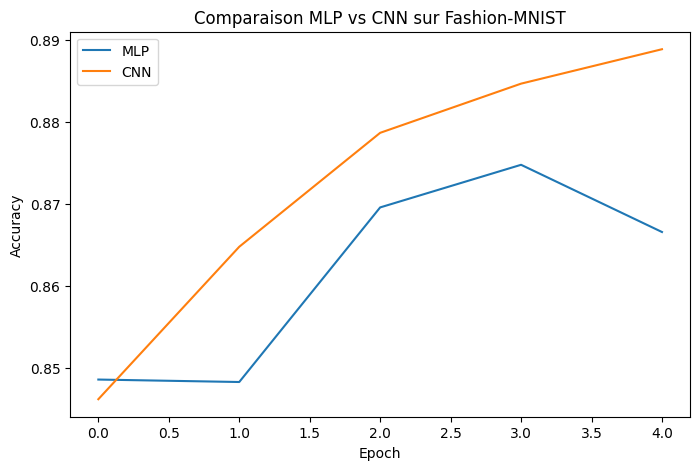

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(mlp_accuracies, label="MLP")
plt.plot(cnn_accuracies, label="CNN")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Comparaison MLP vs CNN sur Fashion-MNIST")
plt.legend()
plt.show()

### Comparaison de la précision finale
Cette cellule imprime les précisions de test finales obtenues par les modèles `ImageMLP` et `LeNetCNN` après 5 époques d'entraînement, fournissant une comparaison numérique directe de leurs performances.

In [ ]:
print("Accuracy finale MLP :", mlp_accuracies[-1])
print("Accuracy finale CNN :", cnn_accuracies[-1])

Accuracy finale MLP : 0.8666
Accuracy finale CNN : 0.8889


### Variante du modèle CNN : sans padding
Cette cellule définit `CNNNoPadding`, une variante du CNN de type LeNet où les couches de convolution n'utilisent aucun padding (`padding=0`). Cela entraînera des cartes de caractéristiques de sortie plus petites par rapport au LeNetCNN original.

In [ ]:
class CNNNoPadding(nn.Module):
    def __init__(self):
        super(CNNNoPadding, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(6, 16, kernel_size=5, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 4 * 4, 120),
            nn.ReLU(),
            nn.Linear(120, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

### Variante du modèle CNN : avec stride
Cette cellule définit `CNNStride`, une variante de CNN qui utilise différentes valeurs de `stride` dans ses couches de convolution (par exemple, `stride=2` dans la première couche) pour réduire les dimensions spatiales des cartes de caractéristiques plus tôt, sans dépendre uniquement des couches de pooling.

In [ ]:
class CNNStride(nn.Module):
    def __init__(self):
        super(CNNStride, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 3 * 3, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

### Variante du modèle CNN : pooling moyen
Cette cellule définit `CNNAveragePooling`, une variante de CNN qui remplace les couches `nn.MaxPool2d` par des couches `nn.AvgPool2d`. Le pooling moyen calcule la moyenne des éléments dans la fenêtre de pooling, ce qui peut parfois conduire à des cartes de caractéristiques plus lisses.

In [ ]:
class CNNAveragePooling(nn.Module):
    def __init__(self):
        super(CNNAveragePooling, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AvgPool2d(2, 2),

            nn.Conv2d(6, 16, kernel_size=5),
            nn.ReLU(),
            nn.AvgPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),
            nn.Linear(120, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

### Variante du modèle CNN : plus de filtres
Cette cellule définit `CNNMoreFilters`, une variante de CNN qui utilise un plus grand nombre de filtres dans ses couches de convolution (par exemple, 16 et 32 filtres). L'augmentation du nombre de filtres permet au modèle d'apprendre des caractéristiques plus diverses.

In [ ]:
class CNNMoreFilters(nn.Module):
    def __init__(self):
        super(CNNMoreFilters, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 5 * 5, 120),
            nn.ReLU(),
            nn.Linear(120, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

### Variante du modèle CNN : convolutions 1x1
Cette cellule définit `CNNWith1x1`, une variante de CNN qui incorpore des couches de convolution 1x1. Les convolutions 1x1 peuvent être utilisées pour la réduction de dimensionnalité (par canal), l'augmentation de la non-linéarité et l'intégration d'informations entre les canaux.

In [ ]:
class CNNWith1x1(nn.Module):
    def __init__(self):
        super(CNNWith1x1, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, padding=2),
            nn.ReLU(),

            nn.Conv2d(16, 8, kernel_size=1),
            nn.ReLU(),

            nn.MaxPool2d(2, 2),

            nn.Conv2d(8, 16, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),
            nn.Linear(120, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

### Réalisation et évaluation des expériences CNN
Cette cellule configure et exécute une série d'expériences avec différentes architectures CNN définies précédemment. Elle itère sur chaque modèle, l'entraîne à l'aide de la fonction `train_model` et stocke ses pertes d'entraînement, ses précisions de test et sa précision finale dans le dictionnaire `results`.

In [ ]:
experiments = {
    "LeNetCNN": LeNetCNN(),
    "NoPadding": CNNNoPadding(),
    "Stride": CNNStride(),
    "AveragePooling": CNNAveragePooling(),
    "MoreFilters": CNNMoreFilters(),
    "With1x1": CNNWith1x1()
}

results = {}

for name, model in experiments.items():
    print("\nModèle :", name)

    losses, accuracies = train_model(
        model,
        train_loader,
        test_loader,
        epochs=5,
        lr=0.001
    )

    results[name] = {
        "losses": losses,
        "accuracies": accuracies,
        "final_accuracy": accuracies[-1]
    }


Modèle : LeNetCNN
Epoch [1/5] - Loss: 0.5999 - Test Accuracy: 0.8441
Epoch [2/5] - Loss: 0.3772 - Test Accuracy: 0.8698
Epoch [3/5] - Loss: 0.3235 - Test Accuracy: 0.8664
Epoch [4/5] - Loss: 0.2954 - Test Accuracy: 0.8760
Epoch [5/5] - Loss: 0.2721 - Test Accuracy: 0.8888

Modèle : NoPadding
Epoch [1/5] - Loss: 0.6110 - Test Accuracy: 0.8353
Epoch [2/5] - Loss: 0.3917 - Test Accuracy: 0.8639
Epoch [3/5] - Loss: 0.3437 - Test Accuracy: 0.8689
Epoch [4/5] - Loss: 0.3121 - Test Accuracy: 0.8780
Epoch [5/5] - Loss: 0.2931 - Test Accuracy: 0.8753

Modèle : Stride
Epoch [1/5] - Loss: 0.7525 - Test Accuracy: 0.7992
Epoch [2/5] - Loss: 0.4807 - Test Accuracy: 0.8210
Epoch [3/5] - Loss: 0.4238 - Test Accuracy: 0.8409
Epoch [4/5] - Loss: 0.3918 - Test Accuracy: 0.8586
Epoch [5/5] - Loss: 0.3693 - Test Accuracy: 0.8613

Modèle : AveragePooling
Epoch [1/5] - Loss: 0.5769 - Test Accuracy: 0.8365
Epoch [2/5] - Loss: 0.3880 - Test Accuracy: 0.8613
Epoch [3/5] - Loss: 0.3406 - Test Accuracy: 0.8763
E

### Affichage des précisions finales de tous les modèles
Cette cellule itère sur le dictionnaire `results` et imprime la précision de test finale pour chacun des modèles CNN expérimentaux, fournissant un résumé rapide de leurs performances.

In [ ]:
for name, result in results.items():
    print(name, ":", result["final_accuracy"])

LeNetCNN : 0.8888
NoPadding : 0.8753
Stride : 0.8613
AveragePooling : 0.8869
MoreFilters : 0.9032
With1x1 : 0.8985


### Résumé des précisions du modèle dans un DataFrame
Cette cellule crée un DataFrame pandas pour afficher clairement les précisions de test finales de tous les modèles CNN expérimentaux, ce qui facilite la comparaison de leurs performances sous forme de tableau.

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Modèle": list(results.keys()),
    "Accuracy finale": [results[name]["final_accuracy"] for name in results]
})

print(comparison_df)

           Modèle  Accuracy finale
0        LeNetCNN           0.8888
1       NoPadding           0.8753
2          Stride           0.8613
3  AveragePooling           0.8869
4     MoreFilters           0.9032
5         With1x1           0.8985


### Fonction de visualisation des cartes de caractéristiques
Cette cellule définit `visualize_feature_maps`, une fonction qui prend un modèle entraîné et une image, puis extrait et affiche les cartes de caractéristiques produites par la première couche de convolution du modèle. Cela aide à comprendre quelles caractéristiques le modèle apprend.

In [ ]:
def visualize_feature_maps(model, image):
    model.eval()

    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        first_conv = model.features[0]
        feature_maps = first_conv(image)

    feature_maps = feature_maps.cpu().squeeze(0)

    num_maps = feature_maps.shape[0]

    plt.figure(figsize=(12, 4))

    for i in range(min(num_maps, 6)):
        plt.subplot(1, 6, i + 1)
        plt.imshow(feature_maps[i], cmap="gray")
        plt.title(f"Map {i+1}")
        plt.axis("off")

    plt.show()

### Visualisation des cartes de caractéristiques pour une image échantillon
Cette cellule sélectionne une image échantillon du `test_dataset`, affiche l'image originale, puis appelle `visualize_feature_maps` pour montrer les cartes de caractéristiques générées par la première couche de convolution du `cnn_model` pour cette image.

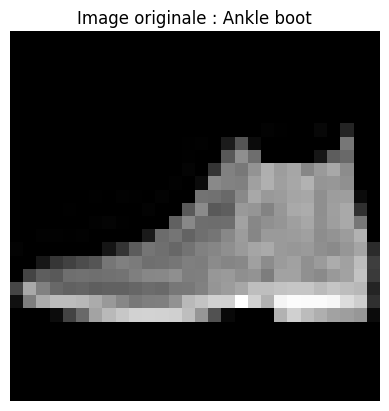

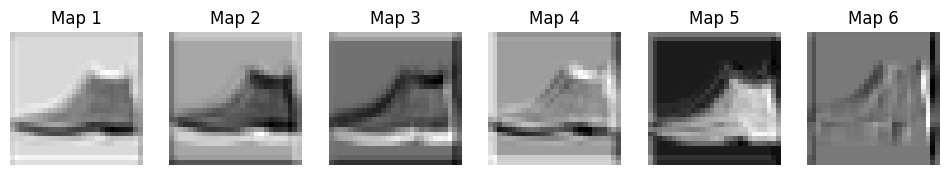

In [ ]:
sample_image, sample_label = test_dataset[0]

plt.imshow(sample_image.squeeze(), cmap="gray")
plt.title("Image originale : " + classes[sample_label])
plt.axis("off")
plt.show()

visualize_feature_maps(cnn_model.to(device), sample_image)

### Fonction d'évaluation complète du modèle
Cette cellule définit `evaluate_model_full`, une fonction complète qui évalue un modèle donné sur un chargeur de données. Elle calcule et imprime diverses métriques, y compris la précision, le rappel, le score F1, un rapport de classification détaillé, et renvoie la matrice de confusion.

In [ ]:
def evaluate_model_full(model, data_loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="macro")
    recall = recall_score(all_labels, all_preds, average="macro")
    f1 = f1_score(all_labels, all_preds, average="macro")
    cm = confusion_matrix(all_labels, all_preds)

    print("Accuracy :", accuracy)
    print("Precision :", precision)
    print("Recall :", recall)
    print("F1-score :", f1)
    print("\nRapport de classification :")
    print(classification_report(all_labels, all_preds, target_names=classes))

    return cm

### Évaluation du LeNetCNN avec toutes les métriques
Cette cellule appelle la fonction `evaluate_model_full` pour obtenir un rapport de performance détaillé pour le `cnn_model` (LeNetCNN) sur le `test_loader`. Elle imprime toutes les métriques calculées et le rapport de classification.

In [ ]:
cm = evaluate_model_full(cnn_model.to(device), test_loader)

Accuracy : 0.8889
Precision : 0.8898283056381991
Recall : 0.8889000000000001
F1-score : 0.8890102686066965

Rapport de classification :
              precision    recall  f1-score   support

 T-shirt/top       0.82      0.84      0.83      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.85      0.82      0.84      1000
       Dress       0.88      0.91      0.89      1000
        Coat       0.85      0.77      0.81      1000
      Sandal       0.96      0.98      0.97      1000
       Shirt       0.68      0.71      0.69      1000
     Sneaker       0.94      0.97      0.95      1000
         Bag       0.96      0.98      0.97      1000
  Ankle boot       0.98      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



### Visualisation de la matrice de confusion
Cette cellule génère et affiche une carte thermique de la matrice de confusion obtenue à partir de l'évaluation complète du `cnn_model`. La matrice de confusion fournit une représentation visuelle des performances de classification du modèle pour chaque classe.

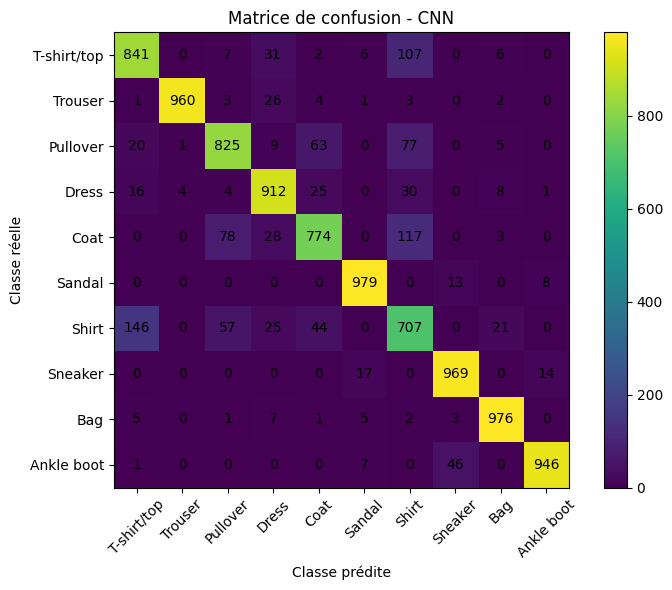

In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Matrice de confusion - CNN")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.colorbar()

plt.xticks(range(10), classes, rotation=45)
plt.yticks(range(10), classes)

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

### Sauvegarde du modèle entraîné
Cette cellule enregistre le dictionnaire d'état entraîné du `cnn_model` (LeNetCNN) dans un fichier nommé 'best_cnn_fashionmnist.pth'. Cela permet de charger et de réutiliser le modèle entraîné ultérieurement sans le réentraîner.

In [ ]:
torch.save(cnn_model.state_dict(), "best_cnn_fashionmnist.pth")
print("Modèle CNN sauvegardé.")

Modèle CNN sauvegardé.


### Chargement et vérification du modèle sauvegardé
Cette cellule démontre comment charger un modèle précédemment sauvegardé. Elle initialise une nouvelle instance de `LeNetCNN`, charge le dictionnaire d'état à partir de 'best_cnn_fashionmnist.pth' et met le modèle en mode évaluation, confirmant le rechargement réussi.

In [ ]:
loaded_cnn = LeNetCNN().to(device)
loaded_cnn.load_state_dict(torch.load("best_cnn_fashionmnist.pth"))
loaded_cnn.eval()

print("Modèle CNN rechargé avec succès.")

Modèle CNN rechargé avec succès.
